# Retail EDA — Smart Retail Intelligence Platform

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clean chart style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded OK')

Libraries loaded OK


In [2]:
df_customers = pd.read_csv('E:/Retail_Analysis/customers.csv')
df_orders = pd.read_csv('E:/Retail_Analysis/orders.csv')
df_order_items = pd.read_csv('E:/Retail_Analysis/order_items.csv')
df_products = pd.read_csv('E:/Retail_Analysis/products.csv')
df_inventory = pd.read_csv('E:/Retail_Analysis/inventory.csv')

In [3]:
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'], errors='coerce')
delivered = df_orders[df_orders['status'] == 'Delivered']

In [4]:
df_master_tbl = (
    df_orders.merge(df_customers, on='customer_id')
             .merge(df_order_items, on='order_id')
             .merge(df_products, on='product_id')
)

#### Rename duplicate columns


In [5]:
df_master_tbl = df_master_tbl.rename(columns={
    'name_x': 'customer_name', 'name_y': 'product_name',
    'city_x': 'city', 'state_x': 'state',
    'discount_pct_x': 'order_discount_pct'
})

In [6]:
print(f'Customers  : {len(df_customers):,}')
print(f'Products   : {len(df_products):,}')
print(f'Orders     : {len(df_orders):,}')
print(f'Order items: {len(df_order_items):,}')
print(f'Inventory  : {len(df_inventory):,}')

Customers  : 1,000
Products   : 200
Orders     : 4,570
Order items: 9,109
Inventory  : 200


In [7]:
df_master_tbl.head()

,order_id,customer_id,order_date,status,payment_method,order_discount_pct,order_total,city,state,customer_name,...,discount_pct_y,line_total,product_name,category,subcategory,brand,cost_price,sell_price,margin_pct,is_active
0,ORD0000001,CUST00001,2022-10-13,Delivered,Credit Card,0,37064.68,Kishanganj,Gujarat,Aryan Maharaj,...,0,3027.00,Nova Adipisci Beauty,Beauty,Nemo,ZenBrand,585.66,756.75,29.2,1
1,ORD0000081,CUST00025,2024-01-28,Delivered,Wallet,0,40316.37,Mango,Punjab,Yagnesh Divan,...,0,3027.00,Nova Adipisci Beauty,Beauty,Nemo,ZenBrand,585.66,756.75,29.2,1
2,ORD0000130,CUST00030,2024-09-05,Delivered,Credit Card,0,12190.80,Mathura,Chhattisgarh,Ladli Mall,...,0,3027.00,Nova Adipisci Beauty,Beauty,Nemo,ZenBrand,585.66,756.75,29.2,1
3,ORD0000156,CUST00035,2023-11-23,Delivered,UPI,10,140363.06,Nagercoil,Tamil Nadu,Vamakshi Swaminathan,...,10,1362.15,Nova Adipisci Beauty,Beauty,Nemo,ZenBrand,585.66,756.75,29.2,1
4,ORD0000175,CUST00038,2024-11-04,Delivered,UPI,0,18902.69,Medininagar,Punjab,Charan Krishnan,...,0,3027.00,Nova Adipisci Beauty,Beauty,Nemo,ZenBrand,585.66,756.75,29.2,1


#### Section 1 — Business KPI Snapshot

In [8]:
delivered = df_orders[df_orders['status'] == 'Delivered']
total_revenue    = delivered['order_total'].sum()
avg_order_value  = delivered['order_total'].mean()
total_orders     = len(df_orders)
total_customers  = len(df_customers)
churn_rate       = df_customers['is_churned'].mean() * 100
cancel_rate      = (df_orders['status'] == 'Cancelled').mean() * 100
items_low_stock  = df_inventory['needs_restock'].sum()
kpis = {
    'Total Revenue (₹)':    f'₹{total_revenue:,.0f}',
    'Avg Order Value':       f'₹{avg_order_value:,.0f}',
    'Total Orders':          f'{total_orders:,}',
    'Total Customers':       f'{total_customers:,}',
    'Churn Rate':            f'{churn_rate:.1f}%',
    'Cancellation Rate':     f'{cancel_rate:.1f}%',
    'Products Needing Restock': f'{items_low_stock}',
}

for k, v in kpis.items():
    print(f'  {k:<28} {v}')


  Total Revenue (₹)            ₹166,631,272
  Avg Order Value              ₹52,137
  Total Orders                 4,570
  Total Customers              1,000
  Churn Rate                   8.4%
  Cancellation Rate            8.3%
  Products Needing Restock     82


#### Section 2 — Sales Trends Over Time

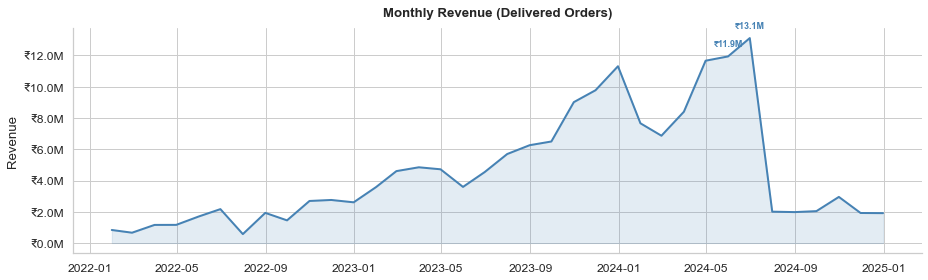

Observation: Notice the November-December spike — this is your seasonal demand signal for forecasting.


In [9]:
monthly = (
    delivered
    .set_index('order_date')
    .resample('M')['order_total']
    .sum()
    .reset_index()
)
monthly.columns = ['month', 'revenue']

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(monthly['month'], monthly['revenue'], alpha=0.15, color='steelblue')
ax.plot(monthly['month'], monthly['revenue'], color='steelblue', linewidth=2)

# Annotate the two highest months
top2 = monthly.nlargest(2, 'revenue')
for _, row in top2.iterrows():
    ax.annotate(
        f"₹{row['revenue']/1e6:.1f}M",
        xy=(row['month'], row['revenue']),
        xytext=(0, 10), textcoords='offset points',
        ha='center', fontsize=9, color='steelblue', fontweight='bold'
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.set_title('Monthly Revenue (Delivered Orders)', fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.show()
print('Observation: Notice the November-December spike — this is your seasonal demand signal for forecasting.')

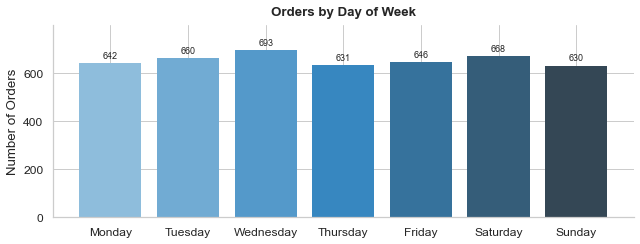

In [10]:
# ── CELL 5: Orders by Day of Week + Hour Heatmap ────────────────────
df_orders['day_of_week'] = df_orders['order_date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_counts = (
    df_orders.groupby('day_of_week').size()
    .reindex(day_order)
    .reset_index()
)
day_counts.columns = ['day', 'orders']

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.bar(day_counts['day'], day_counts['orders'],
              color=sns.color_palette('Blues_d', 7), edgecolor='none')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_title('Orders by Day of Week', fontweight='bold', pad=10)
ax.set_ylabel('Number of Orders')
ax.set_ylim(0, day_counts['orders'].max() * 1.15)
plt.tight_layout()
plt.show()

#### Section 3 — Customer Analysis

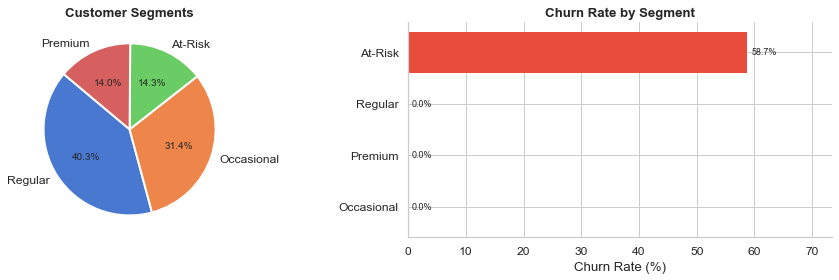

Observation: At-Risk segment has the highest churn — this is the primary target for your XGBoost model.


In [11]:
# ── CELL 6: Customer Segment Distribution + Churn by Segment ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: segment counts
seg_counts = df_customers['segment'].value_counts()
colors = sns.color_palette('muted', len(seg_counts))

axes[0].pie(
    seg_counts.values, labels=seg_counts.index,
    colors=colors, autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Customer Segments', fontweight='bold')

# Right: churn rate per segment
churn_by_seg = (
    df_customers.groupby('segment')['is_churned']
    .mean().mul(100).sort_values(ascending=True)
    .reset_index()
)
churn_by_seg.columns = ['segment', 'churn_rate']
bar_colors = ['#e74c3c' if c > 20 else '#3498db' for c in churn_by_seg['churn_rate']]
bars = axes[1].barh(churn_by_seg['segment'], churn_by_seg['churn_rate'],
                    color=bar_colors, edgecolor='none')
axes[1].bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
axes[1].set_title('Churn Rate by Segment', fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
axes[1].set_xlim(0, churn_by_seg['churn_rate'].max() * 1.25)

plt.tight_layout()
plt.show()
print('Observation: At-Risk segment has the highest churn — this is the primary target for your XGBoost model.')

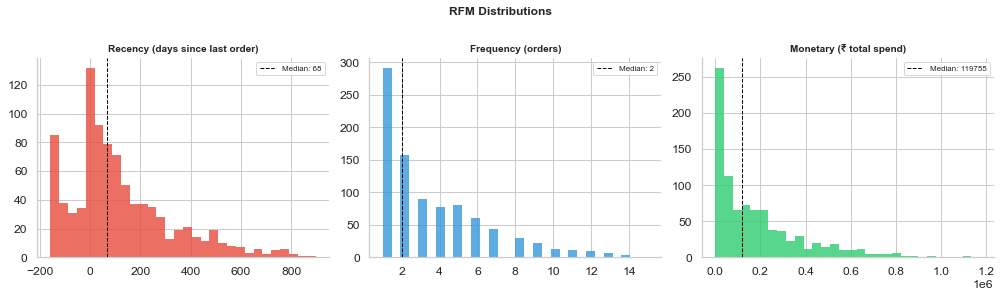


RFM Score Summary:
       recency  frequency   monetary  rfm_score
count    897.0      897.0      897.0      897.0
mean     120.1        3.6   185765.1        9.0
std      202.3        2.9   205004.5        3.5
min     -158.0        1.0      202.4        3.0
25%        2.0        1.0    29250.0        6.0
50%       68.0        2.0   119754.7        9.0
75%      208.0        5.0   264569.4       12.0
max      896.0       15.0  1172988.0       15.0


In [12]:
# ── CELL 7: RFM Analysis ─────────────────────────────────────────────
# R = Recency (days since last order)
# F = Frequency (number of orders)
# M = Monetary (total spend)

SNAPSHOT_DATE = pd.Timestamp('2024-07-01')

delivered_orders = df_orders[df_orders['status'] == 'Delivered'].copy()

rfm = (
    delivered_orders
    .groupby('customer_id')
    .agg(
        recency   = ('order_date', lambda x: (SNAPSHOT_DATE - x.max()).days),
        frequency = ('order_id', 'count'),
        monetary  = ('order_total', 'sum')
    )
    .reset_index()
)

# Score 1-5 (5 = best)
rfm['r_score'] = pd.qcut(rfm['recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'],  5, labels=[1,2,3,4,5]).astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles = ['Recency (days since last order)', 'Frequency (orders)', 'Monetary (₹ total spend)']
cols   = ['recency', 'frequency', 'monetary']
palette = ['#e74c3c', '#3498db', '#2ecc71']

for ax, col, title, color in zip(axes, cols, titles, palette):
    ax.hist(rfm[col], bins=30, color=color, alpha=0.80, edgecolor='none')
    ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1, label=f'Median: {rfm[col].median():.0f}')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('RFM Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nRFM Score Summary:')
print(rfm[['recency','frequency','monetary','rfm_score']].describe().round(1).to_string())

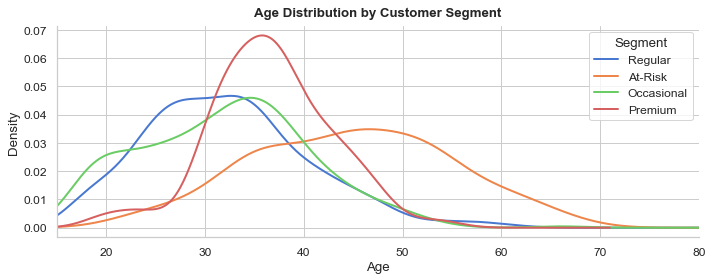

In [13]:
# ── CELL 8: Age Distribution by Segment ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
segments = df_customers['segment'].unique()
palette  = sns.color_palette('muted', len(segments))

for seg, color in zip(segments, palette):
    subset = df_customers[df_customers['segment'] == seg]['age']
    subset.plot.kde(ax=ax, label=seg, color=color, linewidth=2)

ax.set_title('Age Distribution by Customer Segment', fontweight='bold', pad=10)
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend(title='Segment')
ax.set_xlim(15, 80)
plt.tight_layout()
plt.show()

#### Section 4 — Product & Revenue Analysis

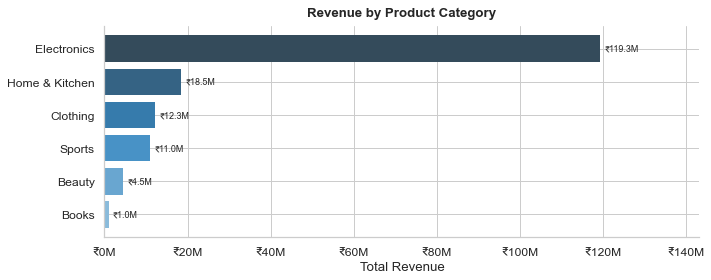

In [14]:
# ── CELL 9: Revenue by Category ──────────────────────────────────────
cat_revenue = (
    df_master_tbl[df_master_tbl['status'] == 'Delivered']
    .groupby('category')['line_total']
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    cat_revenue['category'], cat_revenue['line_total'],
    color=sns.color_palette('Blues_d', len(cat_revenue)), edgecolor='none'
)
ax.bar_label(
    bars,
    labels=[f'₹{v/1e6:.1f}M' for v in cat_revenue['line_total']],
    padding=4, fontsize=9
)
ax.set_title('Revenue by Product Category', fontweight='bold', pad=10)
ax.set_xlabel('Total Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.0f}M'))
ax.set_xlim(0, cat_revenue['line_total'].max() * 1.2)
plt.tight_layout()
plt.show()

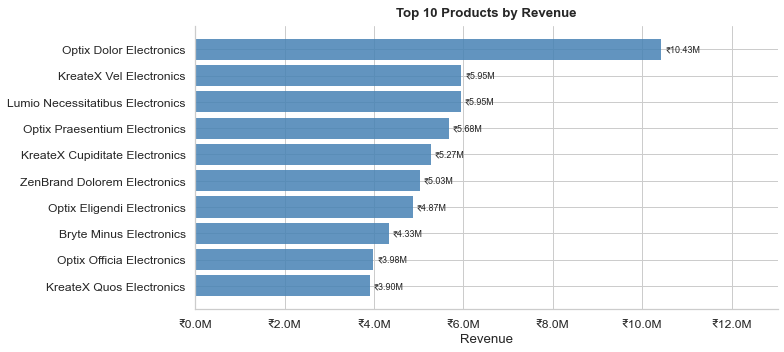

In [15]:
# ── CELL 10: Top 10 Products by Revenue ─────────────────────────────
top_products = (
    df_master_tbl[df_master_tbl['status'] == 'Delivered']
    .groupby('product_name')['line_total']
    .sum()
    .nlargest(10)
    .sort_values(ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    top_products['product_name'], top_products['line_total'],
    color='steelblue', edgecolor='none', alpha=0.85
)
ax.bar_label(
    bars,
    labels=[f'₹{v/1e6:.2f}M' for v in top_products['line_total']],
    padding=4, fontsize=9
)
ax.set_title('Top 10 Products by Revenue', fontweight='bold', pad=10)
ax.set_xlabel('Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.set_xlim(0, top_products['line_total'].max() * 1.25)
plt.tight_layout()
plt.show()

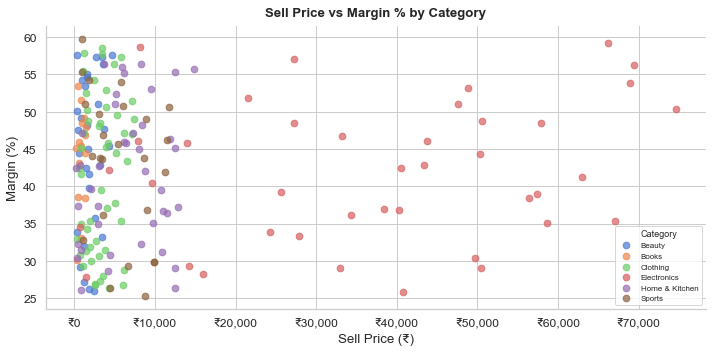

Observation: High-priced Electronics still carry solid margins — good upsell targets.


In [16]:
# ── CELL 11: Margin vs Price Scatter (by Category) ───────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for cat, grp in df_products.groupby('category'):
    ax.scatter(grp['sell_price'], grp['margin_pct'], label=cat, alpha=0.70, s=45)

ax.set_title('Sell Price vs Margin % by Category', fontweight='bold', pad=10)
ax.set_xlabel('Sell Price (₹)')
ax.set_ylabel('Margin (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(title='Category', fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()
print('Observation: High-priced Electronics still carry solid margins — good upsell targets.')

#### Section 5 — Order Behaviour

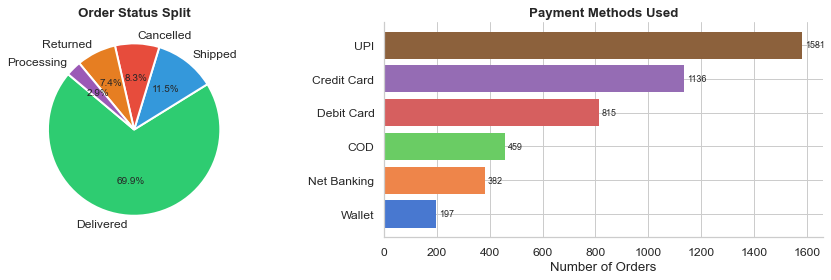

In [17]:
# ── CELL 12: Order Status Breakdown + Payment Methods ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Status
status_counts = df_orders['status'].value_counts()
colors_status = ['#2ecc71','#3498db','#e74c3c','#e67e22','#9b59b6']
axes[0].pie(
    status_counts.values, labels=status_counts.index,
    colors=colors_status[:len(status_counts)],
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Order Status Split', fontweight='bold')

# Payment methods
pay_counts = df_orders['payment_method'].value_counts().sort_values()
axes[1].barh(pay_counts.index, pay_counts.values,
             color=sns.color_palette('muted', len(pay_counts)), edgecolor='none')
for i, v in enumerate(pay_counts.values):
    axes[1].text(v + 10, i, str(v), va='center', fontsize=9)
axes[1].set_title('Payment Methods Used', fontweight='bold')
axes[1].set_xlabel('Number of Orders')

plt.tight_layout()
plt.show()

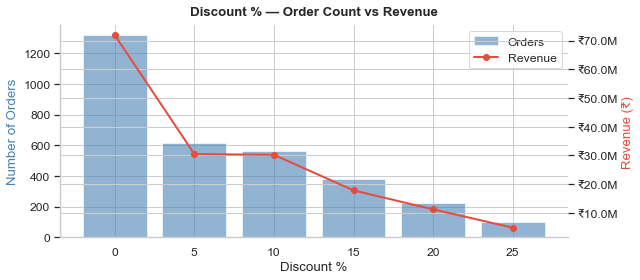

Observation: No-discount orders are highest in count but not always highest in revenue — worth exploring.


In [18]:
# ── CELL 13: Discount Impact on Revenue ─────────────────────────────
disc_revenue = (
    df_orders[df_orders['status'] == 'Delivered']
    .groupby('discount_pct')
    .agg(orders=('order_id','count'), revenue=('order_total','sum'))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.bar(disc_revenue['discount_pct'].astype(str), disc_revenue['orders'],
        color='steelblue', alpha=0.6, label='Orders')
ax2.plot(disc_revenue['discount_pct'].astype(str), disc_revenue['revenue'],
         color='#e74c3c', marker='o', linewidth=2, label='Revenue')

ax1.set_title('Discount % — Order Count vs Revenue', fontweight='bold', pad=10)
ax1.set_xlabel('Discount %')
ax1.set_ylabel('Number of Orders', color='steelblue')
ax2.set_ylabel('Revenue (₹)', color='#e74c3c')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()
print('Observation: No-discount orders are highest in count but not always highest in revenue — worth exploring.')

#### Section 6 — Inventory Health

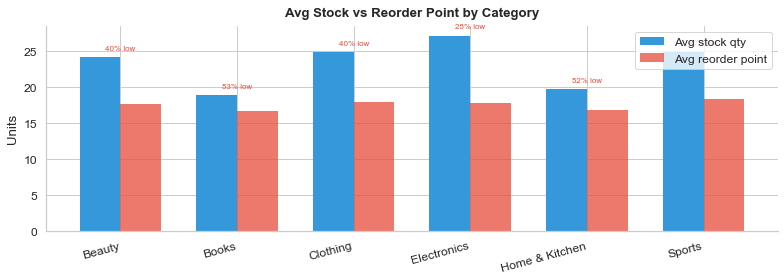

Total products below reorder point: 82 / 200


In [19]:
# ── CELL 14: Inventory Stock vs Reorder Point ────────────────────────
inv_cat = (
    df_inventory.groupby('category')
    .agg(avg_stock=('stock_qty','mean'), avg_reorder=('reorder_point','mean'),
         pct_low=('needs_restock','mean'))
    .reset_index()
)
inv_cat['pct_low'] = inv_cat['pct_low'] * 100

x = np.arange(len(inv_cat))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - width/2, inv_cat['avg_stock'],   width, label='Avg stock qty',    color='#3498db', edgecolor='none')
ax.bar(x + width/2, inv_cat['avg_reorder'], width, label='Avg reorder point', color='#e74c3c', alpha=0.75, edgecolor='none')

ax.set_title('Avg Stock vs Reorder Point by Category', fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(inv_cat['category'], rotation=15, ha='right')
ax.set_ylabel('Units')
ax.legend()

# Annotate % low stock
for i, row in inv_cat.iterrows():
    ax.text(i, max(row['avg_stock'], row['avg_reorder']) + 1,
            f"{row['pct_low']:.0f}% low", ha='center', fontsize=8, color='#e74c3c')

plt.tight_layout()
plt.show()
print(f"Total products below reorder point: {df_inventory['needs_restock'].sum()} / {len(df_inventory)}")

#### Section 7 — Correlation Heatmap (Features for ML)

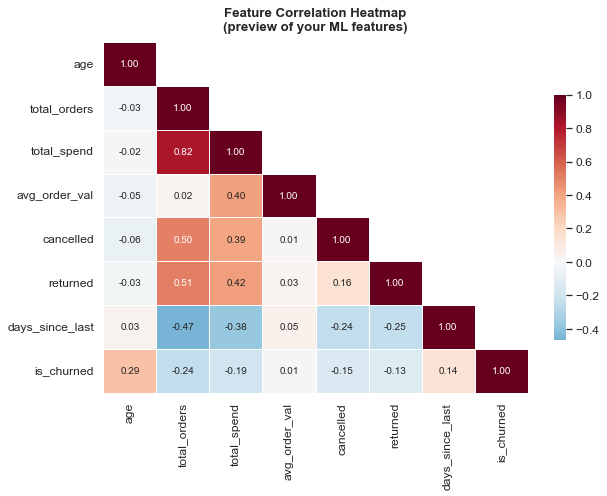

Observation: days_since_last and total_orders are likely your strongest churn predictors.
This customer feature table will be your XGBoost model input in Step 5.


In [20]:
# ── CELL 15: Correlation Heatmap ─────────────────────────────────────
# Build a customer-level feature table (this is your ML input later)
cust_orders = (
    df_orders.groupby('customer_id')
    .agg(
        total_orders  = ('order_id',    'count'),
        total_spend   = ('order_total', 'sum'),
        avg_order_val = ('order_total', 'mean'),
        cancelled     = ('status', lambda x: (x == 'Cancelled').sum()),
        returned      = ('status', lambda x: (x == 'Returned').sum()),
        last_order    = ('order_date',  'max'),
    )
    .reset_index()
)
cust_orders['days_since_last'] = (pd.Timestamp('2024-07-01') - cust_orders['last_order']).dt.days

features = (
    df_customers
    .merge(cust_orders, on='customer_id', how='left')
    .fillna(0)
)

num_cols = ['age','total_orders','total_spend','avg_order_val',
            'cancelled','returned','days_since_last','is_churned']

corr = features[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('Feature Correlation Heatmap\n(preview of your ML features)', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
print('Observation: days_since_last and total_orders are likely your strongest churn predictors.')
print('This customer feature table will be your XGBoost model input in Step 5.')

In [21]:
# ── CELL 16: Save the feature table for ML use later ─────────────────
features.to_csv('E:/Retail_Analysis/customer_features.csv', index=False)
print(f'Saved customer_features.csv — {len(features)} rows, {len(features.columns)} columns')
print('\nColumns:')
print(list(features.columns))
print('\nEDA complete! Your data is clean and ready for ML modelling (Step 5).')

Saved customer_features.csv — 1000 rows, 18 columns

Columns:
['customer_id', 'name', 'email', 'phone', 'city', 'state', 'gender', 'age', 'segment', 'join_date', 'is_churned', 'total_orders', 'total_spend', 'avg_order_val', 'cancelled', 'returned', 'last_order', 'days_since_last']

EDA complete! Your data is clean and ready for ML modelling (Step 5).


## SQL KPI Queries

In [22]:
import sqlite3
import pandas as pd

# Load all your CSV files
df_customers   = pd.read_csv('E:/Retail_Analysis/customers.csv',   parse_dates=['join_date'])
df_products    = pd.read_csv('E:/Retail_Analysis/products.csv')
df_orders      = pd.read_csv('E:/Retail_Analysis/orders.csv',      parse_dates=['order_date'])
df_order_items = pd.read_csv('E:/Retail_Analysis/order_items.csv')
df_inventory   = pd.read_csv('E:/Retail_Analysis/inventory.csv')
df_features    = pd.read_csv('E:/Retail_Analysis/customer_features.csv')

In [23]:
# Create SQLite database
conn = sqlite3.connect('E:/Retail_Analysis/retail.db')

In [24]:
# Write all tables
df_customers.to_sql('customers',         conn, if_exists='replace', index=False)
df_products.to_sql('products',           conn, if_exists='replace', index=False)
df_orders.to_sql('orders',               conn, if_exists='replace', index=False)
df_order_items.to_sql('order_items',     conn, if_exists='replace', index=False)
df_inventory.to_sql('inventory',         conn, if_exists='replace', index=False)
df_features.to_sql('customer_features',  conn, if_exists='replace', index=False)
print('Database created: E:/Retail_Analysis/retail.db')
print('Tables loaded:')
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
for t in tables['name']:
    count = pd.read_sql(f'SELECT COUNT(*) as n FROM {t}', conn)['n'][0]
    print(f'  {t:<25} {count:>6,} rows')

Database created: E:/Retail_Analysis/retail.db
Tables loaded:
  customers                  1,000 rows
  products                     200 rows
  orders                     4,570 rows
  order_items                9,109 rows
  inventory                    200 rows
  customer_features          1,000 rows


#### KPI 1 — Monthly Revenue Trend

In [25]:
query = """
SELECT
    strftime('%Y-%m', order_date)       AS month,
    COUNT(*)                            AS total_orders,
    ROUND(SUM(order_total), 2)          AS revenue,
    ROUND(AVG(order_total), 2)          AS avg_order_value,
    ROUND(
        100.0 * SUM(order_total)
        / SUM(SUM(order_total)) OVER (), 2
    )                                   AS revenue_share_pct
FROM orders
WHERE status = 'Delivered'
GROUP BY month
ORDER BY month
"""

df_monthly = pd.read_sql(query, conn)
print('Monthly Revenue Trend')
print('=' * 62)
print(df_monthly.to_string(index=False))

Monthly Revenue Trend
  month  total_orders     revenue  avg_order_value  revenue_share_pct
2022-01            12   836267.34         69688.95               0.50
2022-02             9   662347.44         73594.16               0.40
2022-03            17  1160294.56         68252.62               0.70
2022-04            18  1163248.66         64624.93               0.70
2022-05            31  1698378.11         54786.39               1.02
2022-06            34  2171158.53         63857.60               1.30
2022-07            25   573254.27         22930.17               0.34
2022-08            29  1931071.48         66588.67               1.16
2022-09            38  1452063.40         38212.19               0.87
2022-10            45  2692423.10         59831.62               1.62
2022-11            62  2757109.35         44469.51               1.65
2022-12            47  2606385.74         55455.02               1.56
2023-01            72  3583045.53         49764.52               2.1

#### KPI 2 — Customer Lifetime Value (CLV) by Segment

In [26]:
query = """
SELECT
    c.segment,
    COUNT(DISTINCT c.customer_id)                               AS customers,
    COUNT(o.order_id)                                           AS total_orders,
    ROUND(SUM(o.order_total), 2)                                AS total_revenue,
    ROUND(SUM(o.order_total) / COUNT(DISTINCT c.customer_id), 2) AS avg_clv,
    ROUND(AVG(o.order_total), 2)                                AS avg_order_value
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
WHERE o.status = 'Delivered'
GROUP BY c.segment
ORDER BY avg_clv DESC
"""

df_clv = pd.read_sql(query, conn)
print('Customer Lifetime Value by Segment')
print('=' * 72)
print(df_clv.to_string(index=False))
print('\nInsight: Premium customers have highest CLV — protect and upsell them.')

Customer Lifetime Value by Segment
   segment  customers  total_orders  total_revenue   avg_clv  avg_order_value
   Premium        139          1080    57412991.97 413043.11         53160.18
   Regular        391          1614    84495512.18 216101.05         52351.62
Occasional        256           371    17995046.25  70293.15         48504.17
   At-Risk        111           131     6727721.22  60610.10         51356.65

Insight: Premium customers have highest CLV — protect and upsell them.


#### KPI 3 — RFM: Top & Bottom Customers

In [27]:
# ── CELL 4: RFM Ranked Customers ────────────────────────────────────
# Business question: Who are our best and most at-risk customers?

query = """
SELECT
    cf.customer_id,
    c.segment,
    c.is_churned,
    cf.total_orders                         AS frequency,
    ROUND(cf.total_spend, 2)                AS monetary,
    cf.days_since_last                      AS recency_days,
    ROUND(cf.avg_order_val, 2)              AS avg_order_val,
    -- RFM composite score (lower recency = better, higher F&M = better)
    ROUND(
        (1.0 / (cf.days_since_last + 1)) * 1000
        + cf.total_orders * 10
        + cf.total_spend / 10000, 2
    )                                       AS rfm_score
FROM customer_features cf
JOIN customers c ON cf.customer_id = c.customer_id
ORDER BY rfm_score DESC
"""

df_rfm = pd.read_sql(query, conn)

print('TOP 10 — Best Customers')
print('=' * 78)
print(df_rfm.head(10).to_string(index=False))

print('\nBOTTOM 10 — Most At-Risk Customers')
print('=' * 78)
print(df_rfm.tail(10).to_string(index=False))

TOP 10 — Best Customers
customer_id    segment  is_churned  frequency   monetary  recency_days  avg_order_val  rfm_score
  CUST00773    Premium           0         12  530752.87             0       44229.41    1173.08
  CUST00301    Regular           0          8  550030.43             0       68753.80    1135.00
  CUST00682    Regular           0          9  254427.66             0       28269.74    1115.44
  CUST00956    Premium           0          7  453536.96             0       64790.99    1115.35
  CUST00127    Regular           0          8  299823.06             0       37477.88    1109.98
  CUST00126    Regular           0          7  372957.11             0       53279.59    1107.30
  CUST00344    Premium           0          6  249571.86             0       41595.31    1084.96
  CUST00237 Occasional           0          1   43563.89             0       43563.89    1014.36
  CUST00935    Premium           0         20 1184294.51             3       59214.73     568.43
  CUST

#### KPI 4 — Product Performance (Revenue + Margin)

In [28]:
# ── CELL 5: Product Performance ──────────────────────────────────────
# Business question: Which products/categories drive the most revenue AND margin?

query = """
SELECT
    p.category,
    COUNT(DISTINCT p.product_id)            AS products,
    SUM(oi.quantity)                        AS units_sold,
    ROUND(SUM(oi.line_total), 2)            AS revenue,
    ROUND(AVG(p.margin_pct), 1)             AS avg_margin_pct,
    ROUND(SUM(oi.line_total)
          / COUNT(DISTINCT p.product_id), 2) AS revenue_per_product,
    -- Window function: rank by revenue
    RANK() OVER (ORDER BY SUM(oi.line_total) DESC) AS revenue_rank
FROM order_items oi
JOIN products p   ON oi.product_id = p.product_id
JOIN orders o     ON oi.order_id   = o.order_id
WHERE o.status = 'Delivered'
GROUP BY p.category
ORDER BY revenue DESC
"""

df_products_kpi = pd.read_sql(query, conn)
print('Product Category Performance')
print('=' * 80)
print(df_products_kpi.to_string(index=False))

Product Category Performance
      category  products  units_sold      revenue  avg_margin_pct  revenue_per_product  revenue_rank
   Electronics        39        3298 119295446.35            42.7           3058857.60             1
Home & Kitchen        34        2887  18520162.58            40.1            544710.66             2
      Clothing        45        4067  12281217.11            42.0            272915.94             3
        Sports        24        2172  11027939.06            43.3            459497.46             4
        Beauty        27        2460   4523615.27            45.9            167541.31             5
         Books        14        1180    982891.25            45.1             70206.52             6


#### KPI 5 — Churn Rate by Segment + Payment Method

In [29]:
# ── CELL 6: Churn Analysis ────────────────────────────────────────────
# Business question: Where is churn concentrated?

# By segment
q1 = """
SELECT
    segment,
    COUNT(*)                                        AS total_customers,
    SUM(is_churned)                                 AS churned,
    ROUND(100.0 * SUM(is_churned) / COUNT(*), 1)    AS churn_pct
FROM customers
GROUP BY segment
ORDER BY churn_pct DESC
"""

# By preferred payment method
q2 = """
SELECT
    o.payment_method,
    COUNT(DISTINCT c.customer_id)                   AS customers,
    SUM(c.is_churned)                               AS churned,
    ROUND(100.0 * SUM(c.is_churned)
          / COUNT(DISTINCT c.customer_id), 1)       AS churn_pct
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY o.payment_method
ORDER BY churn_pct DESC
"""

print('Churn by Segment')
print('=' * 50)
print(pd.read_sql(q1, conn).to_string(index=False))

print('\nChurn by Payment Method')
print('=' * 50)
print(pd.read_sql(q2, conn).to_string(index=False))

Churn by Segment
   segment  total_customers  churned  churn_pct
   At-Risk              143       84       58.7
   Regular              403        0        0.0
   Premium              140        0        0.0
Occasional              314        0        0.0

Churn by Payment Method
payment_method  customers  churned  churn_pct
           UPI        688       39        5.7
   Credit Card        591       32        5.4
   Net Banking        289       10        3.5
    Debit Card        486       16        3.3
           COD        332        8        2.4
        Wallet        168        3        1.8


In [30]:
# ── CELL 8: Export all KPI results to CSV (for Power BI later) ────────
import os
os.makedirs('E:/Retail_Analysis/kpi_exports', exist_ok=True)

exports = {
    'monthly_revenue': """
        SELECT strftime('%Y-%m', order_date) AS month,
               COUNT(*) AS orders,
               ROUND(SUM(order_total),2) AS revenue,
               ROUND(AVG(order_total),2) AS avg_order_value
        FROM orders WHERE status='Delivered'
        GROUP BY month ORDER BY month
    """,
    'clv_by_segment': """
        SELECT c.segment, COUNT(DISTINCT c.customer_id) AS customers,
               ROUND(SUM(o.order_total)/COUNT(DISTINCT c.customer_id),2) AS avg_clv
        FROM customers c JOIN orders o ON c.customer_id=o.customer_id
        WHERE o.status='Delivered' GROUP BY c.segment
    """,
    'product_performance': """
        SELECT p.category, p.product_id,
               SUM(oi.quantity) AS units_sold,
               ROUND(SUM(oi.line_total),2) AS revenue,
               ROUND(AVG(p.margin_pct),1) AS avg_margin_pct
        FROM order_items oi
        JOIN products p ON oi.product_id=p.product_id
        JOIN orders o ON oi.order_id=o.order_id
        WHERE o.status='Delivered'
        GROUP BY p.product_id ORDER BY revenue DESC
    """,
    'churn_summary': """
        SELECT segment, COUNT(*) AS total,
               SUM(is_churned) AS churned,
               ROUND(100.0*SUM(is_churned)/COUNT(*),1) AS churn_pct
        FROM customers GROUP BY segment
    """,
    'inventory_alerts': """
        SELECT p.product_id, p.category, i.stock_qty,
               i.reorder_point, i.needs_restock,
               i.units_sold_total, i.warehouse_location
        FROM inventory i JOIN products p ON i.product_id=p.product_id
    """,
}

for name, q in exports.items():
    df = pd.read_sql(q, conn)
    path = f'E:/Retail_Analysis/kpi_exports/{name}.csv'
    df.to_csv(path, index=False)
    print(f'Saved {path}  ({len(df)} rows)')

conn.close()
print('\nAll KPI CSVs exported to E:/Retail_Analysis/kpi_exports/')
print('These files will be imported into Power BI in Step 7.')

Saved E:/Retail_Analysis/kpi_exports/monthly_revenue.csv  (36 rows)
Saved E:/Retail_Analysis/kpi_exports/clv_by_segment.csv  (4 rows)
Saved E:/Retail_Analysis/kpi_exports/product_performance.csv  (183 rows)
Saved E:/Retail_Analysis/kpi_exports/churn_summary.csv  (4 rows)
Saved E:/Retail_Analysis/kpi_exports/inventory_alerts.csv  (200 rows)

All KPI CSVs exported to E:/Retail_Analysis/kpi_exports/
These files will be imported into Power BI in Step 7.


## Forecasting with Prophet

In [32]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded OK')

Importing plotly failed. Interactive plots will not work.


Libraries loaded OK


In [33]:
# ── CELL 2: Prepare Time Series Data ─────────────────────────────────
# Prophet requires exactly two columns: ds (date) and y (value)

df_orders = pd.read_csv('E:/Retail_Analysis/orders.csv', parse_dates=['order_date'])
delivered = df_orders[df_orders['status'] == 'Delivered'].copy()

# Weekly revenue aggregation
weekly = (
    delivered
    .set_index('order_date')
    .resample('W')['order_total']
    .sum()
    .reset_index()
)
weekly.columns = ['ds', 'y']

# Also build category-level series for multi-series forecast
df_items    = pd.read_csv('E:/Retail_Analysis/order_items.csv')
df_products = pd.read_csv('E:/Retail_Analysis/products.csv')

cat_weekly = (
    delivered
    .merge(df_items, on='order_id')
    .merge(df_products[['product_id','category']], on='product_id')
    .assign(week=lambda d: d['order_date'].dt.to_period('W').dt.start_time)
    .groupby(['week','category'])['line_total']
    .sum()
    .reset_index()
    .rename(columns={'week':'ds', 'line_total':'y'})
)

print(f'Weekly time series: {len(weekly)} weeks')
print(f'Date range: {weekly["ds"].min().date()}  →  {weekly["ds"].max().date()}')
print(f'Avg weekly revenue: ₹{weekly["y"].mean():,.0f}')
print(f'Max weekly revenue: ₹{weekly["y"].max():,.0f}')
print(f'\nWeekly data preview:')
print(weekly.head())

Weekly time series: 153 weeks
Date range: 2022-01-09  →  2024-12-08
Avg weekly revenue: ₹1,089,093
Max weekly revenue: ₹4,577,811

Weekly data preview:
          ds          y
0 2022-01-09  167606.34
1 2022-01-16  345710.54
2 2022-01-23  322950.46
3 2022-01-30       0.00
4 2022-02-06       0.00


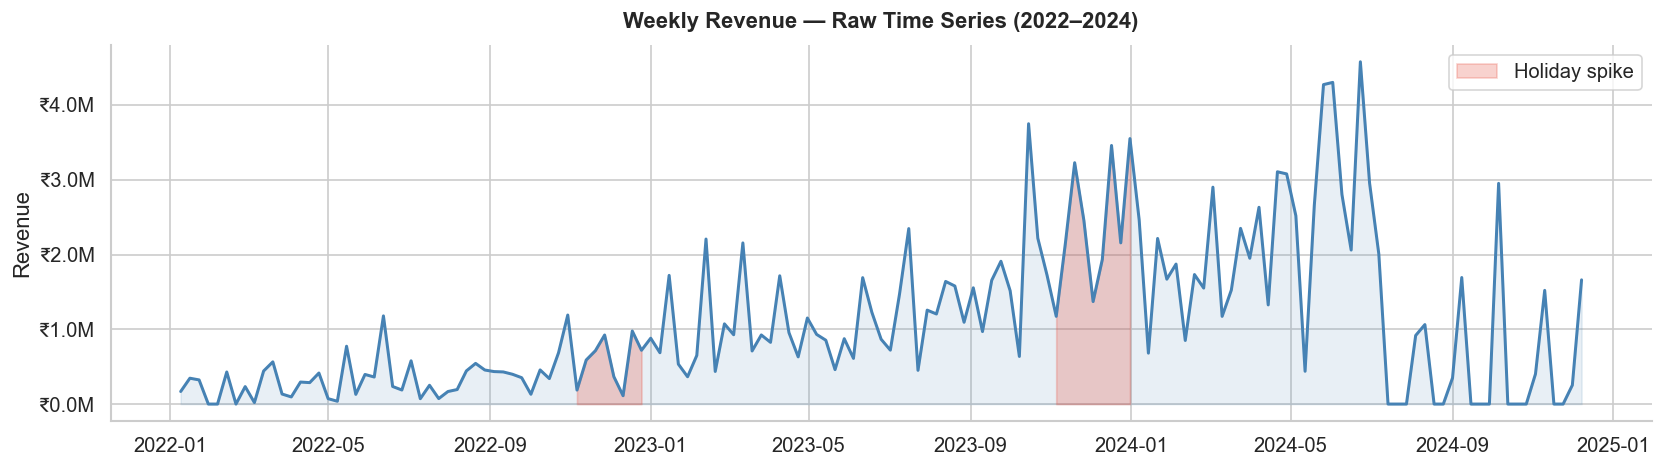

Observation: Clear Nov-Dec holiday spikes — Prophet will learn this seasonality.


In [34]:
# ── CELL 3: Plot Raw Time Series ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(weekly['ds'], weekly['y'], alpha=0.12, color='steelblue')
ax.plot(weekly['ds'], weekly['y'], color='steelblue', linewidth=1.8)

# Highlight Nov-Dec peaks
for year in [2022, 2023]:
    peak = weekly[
        (weekly['ds'].dt.month.isin([11,12])) &
        (weekly['ds'].dt.year == year)
    ]
    ax.fill_between(peak['ds'], peak['y'], alpha=0.25, color='#e74c3c',
                    label='Holiday spike' if year == 2022 else '')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
ax.set_title('Weekly Revenue — Raw Time Series (2022–2024)',
             fontweight='bold', pad=10)
ax.set_xlabel('')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.show()
print('Observation: Clear Nov-Dec holiday spikes — Prophet will learn this seasonality.')

In [35]:
# ── CELL 4: Define Indian Holidays ────────────────────────────────────
# Adding real holidays helps Prophet model demand spikes accurately

indian_holidays = pd.DataFrame({
    'holiday': [
        'Diwali','Diwali','Diwali',
        'Holi','Holi','Holi',
        'Independence Day','Independence Day','Independence Day',
        'Republic Day','Republic Day','Republic Day',
        'Christmas','Christmas','Christmas',
        'New Year','New Year','New Year',
        'Eid','Eid',
        'Navratri Sale','Navratri Sale',
    ],
    'ds': pd.to_datetime([
        '2022-10-24','2023-11-12','2024-11-01',  # Diwali
        '2022-03-18','2023-03-07','2024-03-25',  # Holi
        '2022-08-15','2023-08-15','2024-08-15',  # Independence Day
        '2022-01-26','2023-01-26','2024-01-26',  # Republic Day
        '2022-12-25','2023-12-25','2024-12-25',  # Christmas
        '2022-01-01','2023-01-01','2024-01-01',  # New Year
        '2022-05-02','2023-04-21',               # Eid
        '2022-10-02','2023-10-15',               # Navratri
    ]),
    'lower_window': -2,   # effect starts 2 days before holiday
    'upper_window':  3,   # effect lasts 3 days after
})

print(f'Holidays defined: {indian_holidays["holiday"].nunique()} unique events')
print(indian_holidays[['holiday','ds']].drop_duplicates().to_string(index=False))

Holidays defined: 8 unique events
         holiday         ds
          Diwali 2022-10-24
          Diwali 2023-11-12
          Diwali 2024-11-01
            Holi 2022-03-18
            Holi 2023-03-07
            Holi 2024-03-25
Independence Day 2022-08-15
Independence Day 2023-08-15
Independence Day 2024-08-15
    Republic Day 2022-01-26
    Republic Day 2023-01-26
    Republic Day 2024-01-26
       Christmas 2022-12-25
       Christmas 2023-12-25
       Christmas 2024-12-25
        New Year 2022-01-01
        New Year 2023-01-01
        New Year 2024-01-01
             Eid 2022-05-02
             Eid 2023-04-21
   Navratri Sale 2022-10-02
   Navratri Sale 2023-10-15


In [36]:
# ── CELL 5: Build & Train Prophet Model ───────────────────────────────
model = Prophet(
    holidays              = indian_holidays,
    yearly_seasonality    = True,
    weekly_seasonality    = True,
    daily_seasonality     = False,
    seasonality_mode      = 'multiplicative',  # better for retail (spikes scale with trend)
    changepoint_prior_scale = 0.05,            # how flexible the trend is
    holidays_prior_scale  = 10.0,              # how much holidays affect demand
    interval_width        = 0.90               # 90% confidence interval
)

# Add monthly seasonality (retail patterns change monthly)
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

model.fit(weekly)
print('Prophet model trained!')
print(f'Trained on {len(weekly)} weeks of data')

01:46:57 - cmdstanpy - INFO - Chain [1] start processing
01:46:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained!
Trained on 153 weeks of data


In [37]:
# ── CELL 6: Forecast Next 12 Weeks ───────────────────────────────────
FORECAST_WEEKS = 12

future   = model.make_future_dataframe(periods=FORECAST_WEEKS, freq='W')
forecast = model.predict(future)

# Show only future predictions
future_only = forecast[forecast['ds'] > weekly['ds'].max()][
    ['ds','yhat','yhat_lower','yhat_upper']
].copy()
future_only.columns = ['week','predicted_revenue','lower_bound','upper_bound']
future_only[['predicted_revenue','lower_bound','upper_bound']] = \
    future_only[['predicted_revenue','lower_bound','upper_bound']].round(0)

print(f'12-Week Revenue Forecast')
print('=' * 62)
print(future_only.to_string(index=False))
print(f'\nTotal forecasted revenue (12 weeks): ₹{future_only["predicted_revenue"].sum():,.0f}')

12-Week Revenue Forecast
      week  predicted_revenue  lower_bound  upper_bound
2024-12-15          3231074.0    1988942.0    4396691.0
2024-12-22          5145000.0    3987498.0    6402685.0
2024-12-29          5166666.0    3992637.0    6308826.0
2025-01-05          4148053.0    2873057.0    5346857.0
2025-01-12          1536465.0     308232.0    2704509.0
2025-01-19          1275659.0      97634.0    2531897.0
2025-01-26          1641548.0     482990.0    2894299.0
2025-02-02          2639222.0    1479232.0    3837209.0
2025-02-09          2513302.0    1344376.0    3702489.0
2025-02-16          2316604.0    1119950.0    3661786.0
2025-02-23          2444799.0    1282163.0    3586387.0
2025-03-02          2934460.0    1790104.0    4197752.0

Total forecasted revenue (12 weeks): ₹34,992,852


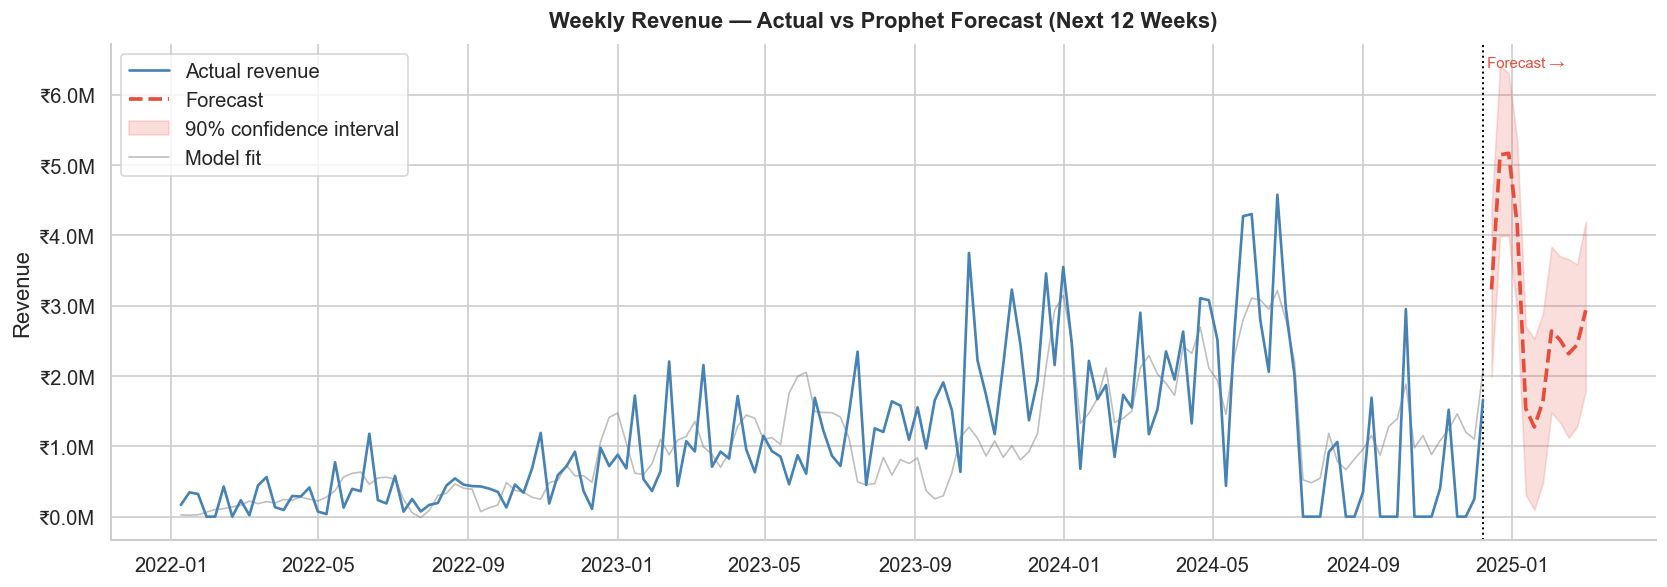

Saved: E:/Retail_Analysis/kpi_exports/demand_forecast.png


In [38]:
# ── CELL 7: Plot Forecast ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Historical actuals
ax.plot(weekly['ds'], weekly['y'], color='steelblue',
        linewidth=1.6, label='Actual revenue', zorder=3)

# Forecast line
forecast_tail = forecast[forecast['ds'] > weekly['ds'].max()]
ax.plot(forecast_tail['ds'], forecast_tail['yhat'],
        color='#e74c3c', linewidth=2.2, linestyle='--',
        label='Forecast', zorder=4)

# Confidence interval
ax.fill_between(
    forecast_tail['ds'],
    forecast_tail['yhat_lower'],
    forecast_tail['yhat_upper'],
    alpha=0.18, color='#e74c3c', label='90% confidence interval'
)

# Fitted values (in-sample)
forecast_in = forecast[forecast['ds'] <= weekly['ds'].max()]
ax.plot(forecast_in['ds'], forecast_in['yhat'],
        color='gray', linewidth=1, alpha=0.5, label='Model fit')

# Divider line
ax.axvline(weekly['ds'].max(), color='black', linestyle=':', linewidth=1.2)
ax.text(weekly['ds'].max(), ax.get_ylim()[1]*0.95,
        ' Forecast →', fontsize=9, color='#e74c3c')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
ax.set_title('Weekly Revenue — Actual vs Prophet Forecast (Next 12 Weeks)',
             fontweight='bold', pad=10)
ax.set_xlabel('')
ax.set_ylabel('Revenue')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('E:/Retail_Analysis/kpi_exports/demand_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: E:/Retail_Analysis/kpi_exports/demand_forecast.png')

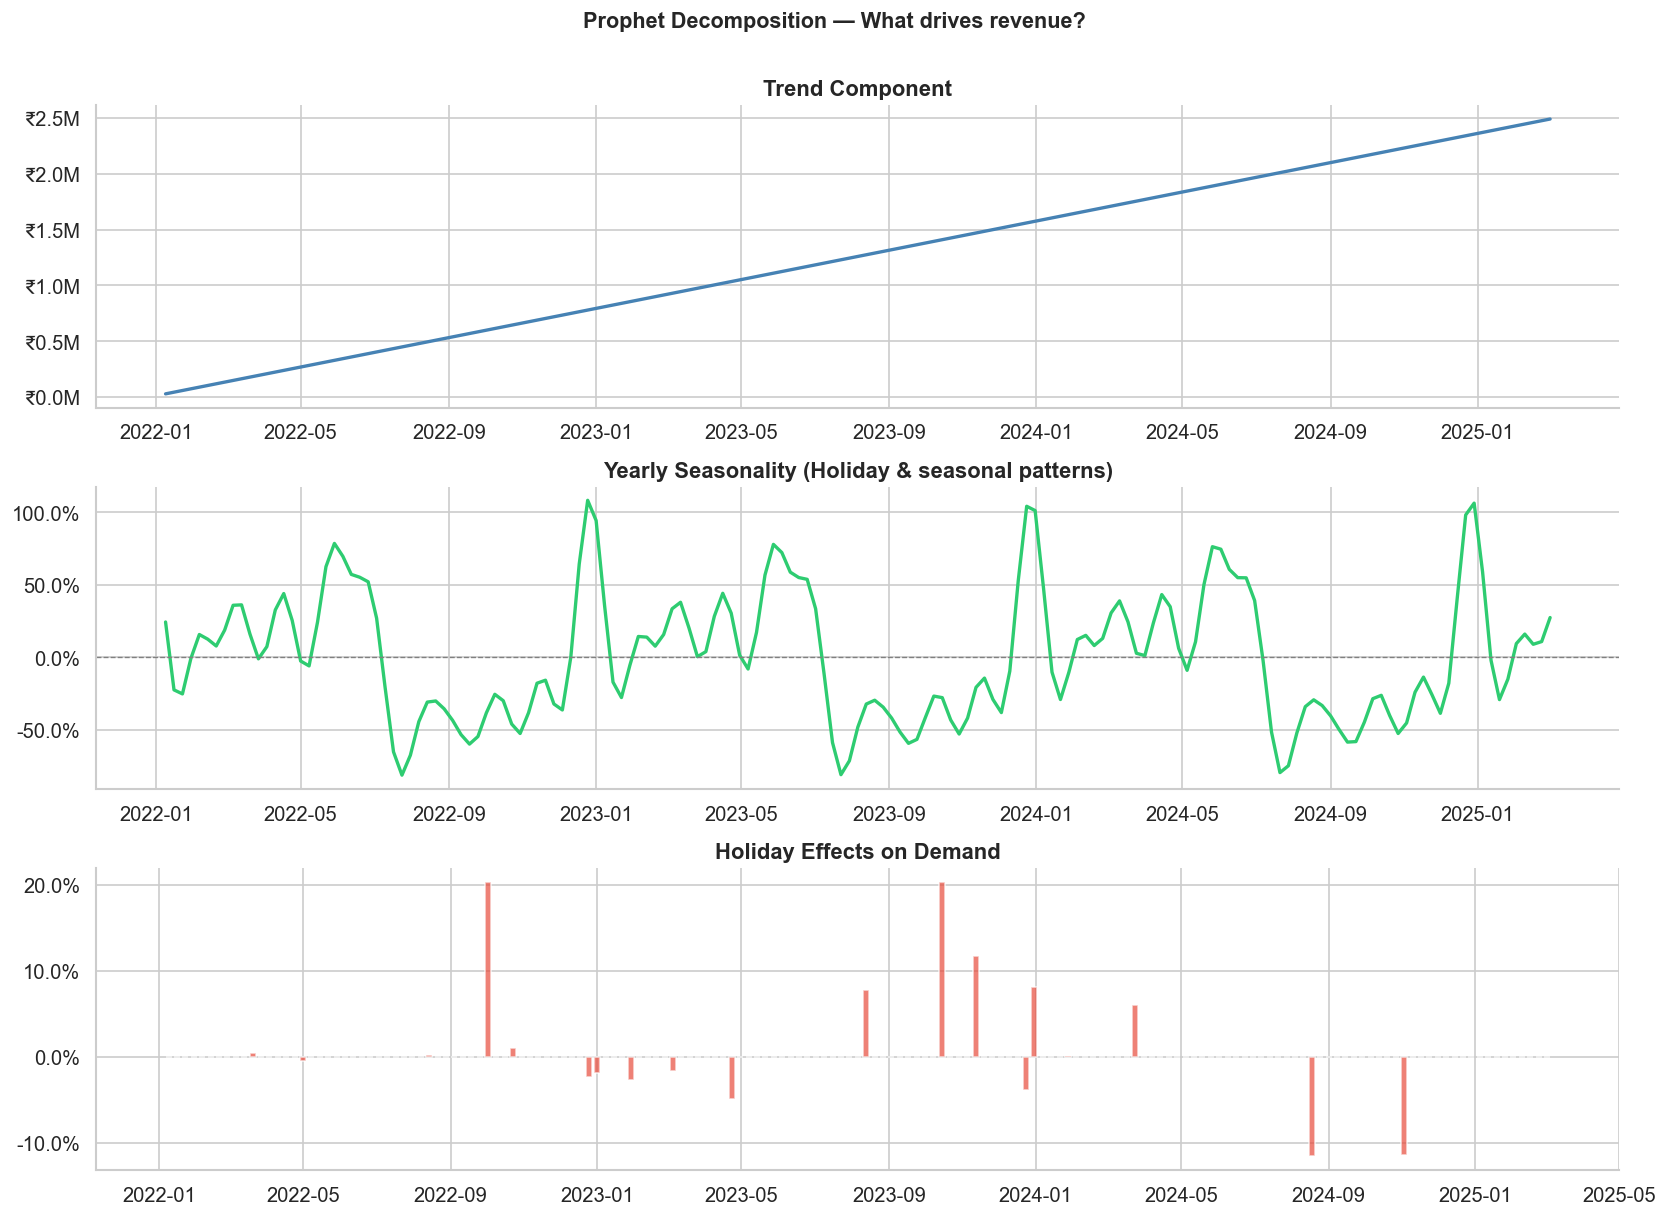

Saved: E:/Retail_Analysis/kpi_exports/forecast_decomposition.png


In [39]:
# ── CELL 8: Decomposition — Trend + Seasonality + Holidays ───────────
# This is the most impressive chart — shows WHAT drives demand

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Trend
axes[0].plot(forecast['ds'], forecast['trend'], color='steelblue', linewidth=2)
axes[0].set_title('Trend Component', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))

# Yearly seasonality
axes[1].plot(forecast['ds'], forecast['yearly'], color='#2ecc71', linewidth=2)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('Yearly Seasonality (Holiday & seasonal patterns)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1%}'))

# Holiday effect
if 'holidays' in forecast.columns:
    axes[2].bar(forecast['ds'], forecast['holidays'],
                color='#e74c3c', alpha=0.7, width=5)
    axes[2].set_title('Holiday Effects on Demand', fontweight='bold')
    axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1%}'))
else:
    axes[2].set_visible(False)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Prophet Decomposition — What drives revenue?',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('E:/Retail_Analysis/kpi_exports/forecast_decomposition.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: E:/Retail_Analysis/kpi_exports/forecast_decomposition.png')

In [44]:
# ── CELL 9: Model Accuracy (Cross-Validation) ─────────────────────────
# Uses walk-forward validation — train on past, test on future windows

print('Running cross-validation (this takes ~30 seconds)...')
df_cv = cross_validation(
    model,
    initial = '365 days',   # train on first 1 year
    period  = '30 days',    # retrain every 30 days
    horizon = '90 days',    # forecast 90 days ahead
    parallel= None
)

metrics = performance_metrics(df_cv)
# print(metrics.columns)
print('\nProphet Cross-Validation Metrics:')
print('=' * 50)
print(metrics[['horizon','mae','rmse','smape']]
      .tail(8)
      .rename(columns={'horizon':'Horizon','mae':'MAE',
                       'rmse':'RMSE','smape':'SMAPE'})
      .to_string(index=False))
print('\nSMAPE = Mean Absolute Percentage Error (lower = better)')
print(f'Average SMAPE: {metrics["smape"].mean()*100:.1f}%')

Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


Running cross-validation (this takes ~30 seconds)...


  0%|          | 0/21 [00:00<?, ?it/s]

01:56:15 - cmdstanpy - INFO - Chain [1] start processing
01:56:16 - cmdstanpy - INFO - Chain [1] done processing
01:56:16 - cmdstanpy - INFO - Chain [1] start processing
01:56:17 - cmdstanpy - INFO - Chain [1] done processing
01:56:17 - cmdstanpy - INFO - Chain [1] start processing
01:56:18 - cmdstanpy - INFO - Chain [1] done processing
01:56:18 - cmdstanpy - INFO - Chain [1] start processing
01:56:19 - cmdstanpy - INFO - Chain [1] done processing
01:56:19 - cmdstanpy - INFO - Chain [1] start processing
01:56:19 - cmdstanpy - INFO - Chain [1] done processing
01:56:20 - cmdstanpy - INFO - Chain [1] start processing
01:56:20 - cmdstanpy - INFO - Chain [1] done processing
01:56:21 - cmdstanpy - INFO - Chain [1] start processing
01:56:21 - cmdstanpy - INFO - Chain [1] done processing
01:56:21 - cmdstanpy - INFO - Chain [1] start processing
01:56:22 - cmdstanpy - INFO - Chain [1] done processing
01:56:22 - cmdstanpy - INFO - Chain [1] start processing
01:56:24 - cmdstanpy - INFO - Chain [1]


Prophet Cross-Validation Metrics:
Horizon          MAE         RMSE    SMAPE
83 days 4.969649e+06 1.829091e+07 0.958154
84 days 4.993453e+06 1.829022e+07 0.926487
85 days 4.902452e+06 1.827731e+07 0.895034
86 days 5.098235e+06 1.832133e+07 0.894763
87 days 5.087032e+06 1.832079e+07 0.829654
88 days 1.054356e+07 3.476301e+07 0.846541
89 days 1.055609e+07 3.476287e+07 0.807353
90 days 7.064103e+06 2.963588e+07 0.735054

MAPE = Mean Absolute Percentage Error (lower = better)
Average SMAPE: 98.3%


In [45]:
# ── CELL 10: Save Forecast for Power BI ───────────────────────────────
# Combine historical + forecast into one clean table

historical = weekly.copy()
historical.columns = ['week', 'actual_revenue']
historical['type'] = 'Actual'

forecast_export = future_only.copy()
forecast_export = forecast_export.rename(columns={'week':'week'})
forecast_export['actual_revenue'] = None
forecast_export['type'] = 'Forecast'

# Full table for Power BI
full_forecast = pd.concat([
    historical.assign(predicted_revenue=None, lower_bound=None, upper_bound=None),
    forecast_export
], ignore_index=True)

full_forecast.to_csv('E:/Retail_Analysis/kpi_exports/demand_forecast.csv', index=False)

# Also save category-level forecast (bonus)
category_summary = (
    cat_weekly
    .groupby(['category', cat_weekly['ds'].dt.to_period('M').rename('month')])
    ['y'].sum()
    .reset_index()
)
category_summary['month'] = category_summary['month'].astype(str)
category_summary.to_csv('E:/Retail_Analysis/kpi_exports/category_monthly_revenue.csv', index=False)

print('Saved: E:/Retail_Analysis/kpi_exports/demand_forecast.csv')
print('Saved: E:/Retail_Analysis/kpi_exports/category_monthly_revenue.csv')
print()
print('Your kpi_exports/ folder now has:')
import os
for f in sorted(os.listdir('E:/Retail_Analysis/kpi_exports/')):
    size = os.path.getsize(f'E:/Retail_Analysis/kpi_exports/{f}')
    print(f'  {f:<45} {size/1024:.1f} KB')
print()
print('Step 6 COMPLETE!')
print('Next: Step 7 — Power BI Dashboard (import all kpi_exports/ files)')

Saved: E:/Retail_Analysis/kpi_exports/demand_forecast.csv
Saved: E:/Retail_Analysis/kpi_exports/category_monthly_revenue.csv

Your kpi_exports/ folder now has:
  category_monthly_revenue.csv                  6.4 KB
  churn_summary.csv                             0.1 KB
  clv_by_segment.csv                            0.1 KB
  demand_forecast.csv                           5.6 KB
  demand_forecast.png                           192.1 KB
  forecast_decomposition.png                    162.9 KB
  inventory_alerts.csv                          7.6 KB
  monthly_revenue.csv                           1.2 KB
  product_performance.csv                       6.9 KB

Step 6 COMPLETE!
Next: Step 7 — Power BI Dashboard (import all kpi_exports/ files)
